---
title: Project 1 — Classification Pipeline (591)
---

*Built with Grok Build*

Course: **EEE591 / EEE419 Python for Rapid Engineering Solutions**.

Heart-disease classification benchmark: train/test split, scaling, and comparison of classical
classifiers (Perceptron, logistic regression, SVM, decision tree, random forest, k-NN) plus voting ensembles.


In [1]:
##########################################################################################
# EEE591_419 Python for Rapid Engineering Solutions - Project 1: project_1_591.py
# Mark Khusid
##########################################################################################

##########################################################################################
# Project 1 591
##########################################################################################


## Problem 1 - 591


### Import Machine Learning Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Perceptron
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score


### Read Database


In [3]:
# Read data
heart = pd.read_csv("heart1.csv")


### Create Accuracy Results Dictionary


In [4]:
accuracy_results_dict = {}


### Separate Features and Labels in Arrays


In [5]:
X = heart.iloc[:, :-1]
y = heart.iloc[:, -1]


## Annotated EDA plots

Class balance and a correlation overview for the heart-disease label.


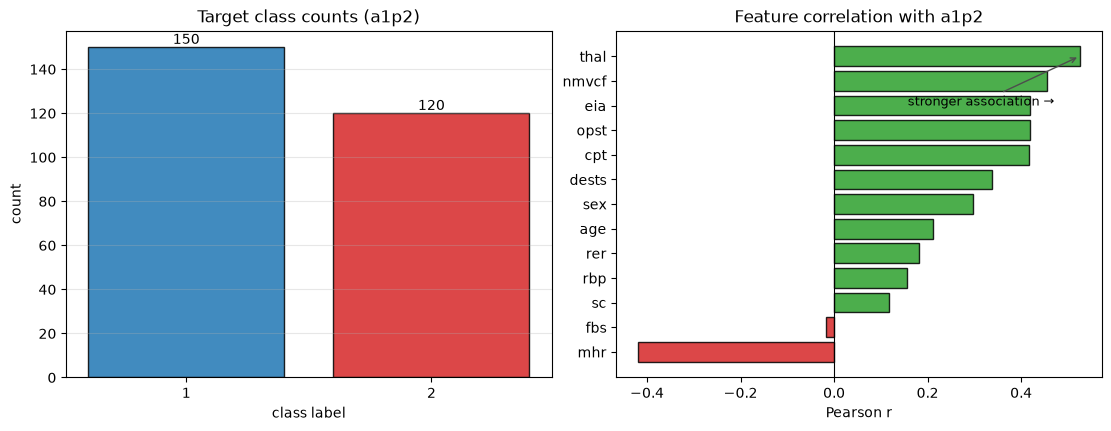

a1p2
1    150
2    120
Name: count, dtype: int64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)

# Class distribution
counts = y.value_counts().sort_index()
axes[0].bar(counts.index.astype(str), counts.values, color=["C0", "C3"], edgecolor="k", alpha=0.85)
axes[0].set_title("Target class counts (a1p2)")
axes[0].set_xlabel("class label")
axes[0].set_ylabel("count")
for i, v in enumerate(counts.values):
    axes[0].annotate(str(v), xy=(i, v), ha="center", va="bottom", fontsize=10)
axes[0].grid(True, axis="y", alpha=0.3)

# Correlation of features with target
corr_t = heart.corr(numeric_only=True)[y.name].drop(y.name).sort_values()
colors = ["C3" if v < 0 else "C2" for v in corr_t.values]
axes[1].barh(corr_t.index.astype(str), corr_t.values, color=colors, edgecolor="k", alpha=0.85)
axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_title(f"Feature correlation with {y.name}")
axes[1].set_xlabel("Pearson r")
axes[1].annotate("stronger association →",
                xy=(float(corr_t.max()), len(corr_t)-1),
                xytext=(float(corr_t.max())*0.3, len(corr_t)-3),
                arrowprops=dict(arrowstyle="->", color="0.3"), fontsize=9)
plt.show()
print(counts)


In [7]:
print(heart.shape)


(270, 14)


In [8]:
print(X.shape)


(270, 13)


In [9]:
print(y.shape)


(270,)


In [10]:
print(X[:5])


   age  sex  cpt  rbp   sc  fbs  rer  mhr  eia  opst  dests  nmvcf  thal
0   29    1    2  130  204    0    2  202    0   0.0      1      0     3
1   34    0    2  118  210    0    0  192    0   0.7      1      0     3
2   34    1    1  118  182    0    2  174    0   0.0      1      0     3
3   35    1    4  120  198    0    0  130    1   1.6      2      0     7
4   35    1    4  126  282    0    2  156    1   0.0      1      0     7


In [11]:
print(y[:5])


0    1
1    1
2    1
3    2
4    2
Name: a1p2, dtype: int64


### Train / Test Split


In [12]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=0,
    stratify=y
)


In [13]:
print(X_train[:5])


     age  sex  cpt  rbp   sc  fbs  rer  mhr  eia  opst  dests  nmvcf  thal
5     35    0    4  138  183    0    0  182    0   1.4      1      0     3
221   63    0    3  135  252    0    2  172    0   0.0      1      0     3
131   54    1    4  120  188    0    0  113    0   1.4      2      1     7
162   58    1    4  146  218    0    0  105    0   2.0      2      1     7
222   63    1    4  130  330    1    2  132    1   1.8      1      3     7


In [14]:
print(y_train[:5])


5      1
221    1
131    2
162    2
222    2
Name: a1p2, dtype: int64


In [15]:
print(X_test[:5])


     age  sex  cpt  rbp   sc  fbs  rer  mhr  eia  opst  dests  nmvcf  thal
63    47    1    4  112  204    0    0  143    0   0.1      1      0     3
254   68    0    3  120  211    0    2  115    0   1.5      2      0     3
234   65    0    3  140  417    1    2  157    0   0.8      1      1     3
56    46    1    4  140  311    0    0  120    1   1.8      2      2     7
151   57    1    4  150  276    0    2  112    1   0.6      2      1     6


In [16]:
print(y_test[:5])


63     1
254    1
234    1
56     2
151    2
Name: a1p2, dtype: int64


### Scale the Training Data


In [17]:
# Standardize for algorithms that need it
sc = StandardScaler()

X_train_std = sc.fit_transform(X_train)
X_test_std = sc.transform(X_test)


In [18]:
print(X_train_std[:2])


[[-2.13215039 -1.44857194  0.91284121  0.33910277 -1.27655761 -0.41702883
  -1.05441535  1.46025029 -0.74965557  0.19486735 -1.01600102 -0.70081094
  -0.90758271]
 [ 0.91246371 -1.44857194 -0.16545247  0.17766594  0.01897451 -0.41702883
   0.95855941  1.02861547 -0.74965557 -0.97433673 -1.01600102 -0.70081094
  -0.90758271]]


In [19]:
print(X_test_std[:2])


[[-0.82731577  0.69033506  0.91284121 -1.06001648 -0.88226523 -0.41702883
  -1.05441535 -0.22312551 -0.74965557 -0.89082215 -1.01600102 -0.70081094
  -0.90758271]
 [ 1.4561448  -1.44857194 -0.16545247 -0.62951825 -0.75083443 -0.41702883
   0.95855941 -1.43170301 -0.74965557  0.27838192  0.58420058 -0.70081094
  -0.90758271]]


## Perceptron


In [20]:
# Perceptron
ppn = Perceptron(
    max_iter=100,
    eta0=0.0001,
    tol=1e-6,
    #fit_intercept=True,
    random_state=0,
    verbose=False
)


In [21]:
ppn.fit(X_train_std, y_train);


In [22]:
y_pred_perceptron = ppn.predict(X_test_std)


In [23]:
print(y_pred_perceptron[0:10])


[1 1 1 2 2 1 1 1 2 2]


In [24]:
print(y_test.iloc[0:10].values)


[1 1 1 2 2 1 1 2 2 2]


### Get Accuracy


In [25]:
print("Perceptron Results:")


Perceptron Results:


In [26]:
preceptron_train_acc = accuracy_score(y_train, ppn.predict(X_train_std))
print(f"Perceptron training accuracy = {preceptron_train_acc:.3f}")


Perceptron training accuracy = 0.847

In [27]:
perceptron_acc = accuracy_score(y_test, y_pred_perceptron)
print(f"Perceptron testing accuracy = {perceptron_acc:.3f}")


Perceptron testing accuracy = 0.815


In [28]:
# Note that this only counts the samples where the predicted value was wrong
print(f'Misclassified: {(y_test != y_pred_perceptron).sum():.0f} out of {len(y_test):.0f} samples.')  # how'd we do?
print(f'Accuracy: {perceptron_acc:.3f}')


Misclassified: 15 out of 81 samples.
Accuracy: 0.815


In [29]:
print(f"    Accuracy: {100*perceptron_acc:.2f}%")


    Accuracy: 81.48%


In [30]:
accuracy_results_dict.update(
    {
        "Perceptron": [perceptron_acc, y_pred_perceptron]
    })


In [31]:
print(accuracy_results_dict)


{'Perceptron': [0.8148148148148148, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 1, 1, 2, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1])]}


### Get Combined Accuracy


In [32]:
X_combined_std = np.vstack((X_train_std, X_test_std))
y_combined = np.hstack((y_train, y_test))
print('Number in combined ',len(y_combined))


Number in combined  270


In [33]:
y_combined_pred = ppn.predict(X_combined_std)


In [34]:
print(y_combined_pred[0:10])


[1 1 2 2 2 2 1 2 2 1]


In [35]:
print(y_combined[0:10])


[1 1 2 2 2 2 2 2 2 1]


In [36]:
perceptron_combined_acc = accuracy_score(y_combined, y_combined_pred)
print(f"Perceptron combined data training accuracy = {perceptron_combined_acc:.3f}")


Perceptron combined data training accuracy = 0.837


In [37]:
# Note that this only counts the samples where the predicted value was wrong
print(f'Misclassified: {(y_combined != y_combined_pred).sum():.0f} out of {len(y_combined):.0f} samples.')  # how'd we do?
print(f'Accuracy: {perceptron_combined_acc:.3f}')


Misclassified: 44 out of 270 samples.
Accuracy: 0.837


In [38]:
print(f"    Combined: {perceptron_combined_acc:.3f}")
print()


    Combined: 0.837



In [39]:
#accuracy_results_dict.update(
#    {
#        "Perceptron_combined": perceptron_combined_acc
#    })


In [40]:
print(accuracy_results_dict)


{'Perceptron': [0.8148148148148148, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 1, 1, 2, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1])]}


## Logistic Regression


In [41]:
#from inspect import signature

#print(signature(LogisticRegression))


In [42]:
# Logistic Regression
LR_accuracy_list = []
c_vals = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
#for c_val in c_vals:
#    lr = LogisticRegression(
#        C            = c_val,
#        solver       = "liblinear",
#        max_iter     = 1000,
#        random_state = 0
#    )
    
#    lr.fit(X_train_std, y_train)
    
#    acc = accuracy_score(y_test, lr.predict(X_test_std))

#    LR_accuracy_list.append(acc)


In [43]:
#print(LR_accuracy_list)


In [44]:
#LR_accuracy_max = max(LR_accuracy_list)
#print(LR_accuracy_max)


In [45]:
#LR_accuracy_max_index = np.argmax(np.array(LR_accuracy_list))
#print(LR_accuracy_max_index)


In [46]:
# Best accuracy with index 1
LR_accuracy_max_index = 1


In [47]:
lr_used = \
    LogisticRegression(
        C            = c_vals[LR_accuracy_max_index],
        solver       = "liblinear",
        max_iter     = 1000,
        random_state = 0
    )
    
lr_used.fit(X_train_std, y_train);


In [48]:
y_pred_LR = lr_used.predict(X_test_std)


In [49]:
print(y_pred_LR[0:10])


[1 1 1 2 2 1 1 1 2 2]


In [50]:
print(y_test.iloc[0:10].values)


[1 1 1 2 2 1 1 2 2 2]


### Get Accuracy


In [51]:
print("Logistic Regression Results:")


Logistic Regression Results:


In [52]:
lr_train_acc = accuracy_score(y_train, lr_used.predict(X_train_std))
print(f"Logistic Regression training accuracy = {lr_train_acc:.3f}")


Logistic Regression training accuracy = 0.873


In [53]:
lr_acc = accuracy_score(y_test, y_pred_LR)
print(f"Logistic Regression testing accuracy = {lr_acc:.3f}")


Logistic Regression testing accuracy = 0.864


In [54]:
print(f'Misclassified: {(y_test != y_pred_LR).sum():.0f} out of {len(y_test):.0f} samples.')  # how'd we do?
print(f'Accuracy: {lr_acc:.3f}')


Misclassified: 11 out of 81 samples.
Accuracy: 0.864


In [55]:
print(f"    Accuracy: {100*lr_acc:.2f}%")


    Accuracy: 86.42%


In [56]:
accuracy_results_dict.update(
    {
        "LR": [lr_acc, y_pred_LR]
    })


In [57]:
print(accuracy_results_dict)


{'Perceptron': [0.8148148148148148, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 1, 1, 2, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1])], 'LR': [0.8641975308641975, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1])]}


### Get Combined Accuracy


In [58]:
lr_combined_used = \
    LogisticRegression(
        C            = c_vals[LR_accuracy_max_index],
        solver       = "liblinear",
        max_iter     = 1000,
        random_state = 0
    )
    
lr_combined_used.fit(X_combined_std, y_combined);


In [59]:
y_combined_pred = lr_combined_used.predict(X_combined_std)


In [60]:
print(y_combined_pred[0:10])


[1 1 2 2 2 2 1 2 2 1]


In [61]:
print(y_combined[0:10])


[1 1 2 2 2 2 2 2 2 1]


In [62]:
lr_combined_acc = accuracy_score(y_combined, y_combined_pred)
print(f"Logistic Regression combined data testing accuracy = {lr_combined_acc:.3f}")


Logistic Regression combined data testing accuracy = 0.852


In [63]:
print(f'Misclassified: {(y_combined != y_combined_pred).sum():.0f} out of {len(y_combined):.0f} samples.')  # how'd we do?
print(f'Accuracy: {lr_combined_acc:.3f}')


Misclassified: 40 out of 270 samples.
Accuracy: 0.852


In [64]:
print(f"    Combined Accuracy: {lr_combined_acc:.3f}")
print()


    Combined Accuracy: 0.852



In [65]:
#accuracy_results_dict.update(
#    {
#        "LR_combined": lr_combined_acc
#    })


In [66]:
print(accuracy_results_dict)


{'Perceptron': [0.8148148148148148, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 1, 1, 2, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1])], 'LR': [0.8641975308641975, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1])]}


## Support Vector Machine


In [67]:
#from inspect import signature

#print(signature(SVC))


In [68]:
#SVM_accuracy_list = []
#degree_vals = list(range(0,7))

#for degree in degree_vals:
#    svm = SVC(
#        C            = 0.01,
#        degree       = degree,
#        kernel       = "linear",
#        max_iter     = -1,
#        random_state = 0
#    )
    
#    svm.fit(X_train_std, y_train)
    
#    acc = accuracy_score(y_test, svm.predict(X_test_std))

#    SVM_accuracy_list.append(acc)


In [69]:
#print(SVM_accuracy_list)


In [70]:
SVM_accuracy_list = []
c_vals = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

#for c_val in c_vals:
#    svm = SVC(
#        C            = c_val,
#        kernel       = "linear",
#        max_iter     = -1,
#        random_state = 0
#    )
    
#    svm.fit(X_train_std, y_train)
    
#    acc = accuracy_score(y_test, svm.predict(X_test_std))

#    SVM_accuracy_list.append(acc)


In [71]:
#print(SVM_accuracy_list)


In [72]:
#SVM_accuracy_max = max(SVM_accuracy_list)
#print(SVM_accuracy_max)


In [73]:
#SVM_accuracy_max_index = np.argmax(np.array(SVM_accuracy_list))
#print(SVM_accuracy_max_index)


In [74]:
# Best accuracy index = 1
SVM_accuracy_max_index = 1


In [75]:
SVM_used = \
    SVC(
        C            = c_vals[SVM_accuracy_max_index],
        kernel       = "linear",
        max_iter     = -1,
        random_state = 0,
        verbose      = False
    )
    
SVM_used.fit(X_train_std, y_train);


In [76]:
y_pred_SVM = SVM_used.predict(X_test_std)


In [77]:
print(y_pred_SVM[0:10])


[1 1 1 2 2 1 1 1 2 2]


In [78]:
print(y_test.iloc[0:10].values)


[1 1 1 2 2 1 1 2 2 2]


### Get Accuracy


In [79]:
print("Support Vector Machine Results:")


Support Vector Machine Results:


In [80]:
SVM_train_acc = accuracy_score(y_train, SVM_used.predict(X_train_std))
print(f"SVM training accuracy = {SVM_train_acc:.3f}")


SVM training accuracy = 0.868


In [81]:
SVM_acc = accuracy_score(y_test, y_pred_SVM)
print(f"SVM testing accuracy = {SVM_acc:.3f}")


SVM testing accuracy = 0.852


In [82]:
print(f'Misclassified: {(y_test != y_pred_SVM).sum():.0f} out of {len(y_test):.0f} samples.')  # how'd we do?
print(f'Accuracy: {SVM_acc:.3f}')


Misclassified: 12 out of 81 samples.
Accuracy: 0.852


In [83]:
print(f"    Accuracy: {100*SVM_acc:.2f}%")


    Accuracy: 85.19%


In [84]:
accuracy_results_dict.update(
    {
        "SVM": [SVM_acc, y_pred_SVM]
    })


In [85]:
print(accuracy_results_dict)


{'Perceptron': [0.8148148148148148, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 1, 1, 2, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1])], 'LR': [0.8641975308641975, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1])], 'SVM': [0.8518518518518519, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1])]}


### Get Combined Accuracy


In [86]:
SVM_combined_used = \
    SVC(
        C            = c_vals[SVM_accuracy_max_index],
        kernel       = "linear",
        max_iter     = -1,
        random_state = 0,
        verbose      = False
    )
    
SVM_combined_used.fit(X_combined_std, y_combined);


In [87]:
y_combined_pred = SVM_combined_used.predict(X_combined_std)


In [88]:
print(y_combined_pred[0:10])


[1 1 2 2 2 2 1 2 2 1]


In [89]:
print(y_combined[0:10])


[1 1 2 2 2 2 2 2 2 1]


In [90]:
SVM_combined_acc = accuracy_score(y_combined, y_combined_pred)
print(f"SVM combined data testing accuracy = {SVM_combined_acc:.3f}")


SVM combined data testing accuracy = 0.859


In [91]:
print(f'Misclassified: {(y_combined != y_combined_pred).sum():.0f} out of {len(y_combined):.0f} samples.')  # how'd we do?
print(f'Accuracy: {SVM_combined_acc:.3f}')


Misclassified: 38 out of 270 samples.
Accuracy: 0.859


In [92]:
print(f"    Combined Accuracy: {SVM_combined_acc:.3f}")
print()


    Combined Accuracy: 0.859



In [93]:
#accuracy_results_dict.update(
#    {
#        "SVM_combined": SVM_combined_acc
#    })


In [94]:
print(accuracy_results_dict)


{'Perceptron': [0.8148148148148148, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 1, 1, 2, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1])], 'LR': [0.8641975308641975, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1])], 'SVM': [0.8518518518518519, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1])]}


## Decision Tree


In [95]:
#from inspect import signature

#print(signature(DecisionTreeClassifier))


In [96]:
print(list(range(1,11)))


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


In [97]:
#DTree_accuracy_list = []
#depth_vals = list(range(1,11))

#for depth in depth_vals:
#    tree = DecisionTreeClassifier(
#        criterion       = 'entropy',
#        max_depth       = depth,
#        random_state    = 0
#    )
    
#    tree.fit(X_train_std, y_train)
    
#    acc = accuracy_score(y_test, tree.predict(X_test_std))

#    DTree_accuracy_list.append(acc)


In [98]:
#print(DTree_accuracy_list)


In [99]:
DTree_accuracy_list = []
depth_vals = list(range(1,11))

#for depth in depth_vals:
#    tree = DecisionTreeClassifier(
#        criterion       = 'gini',
#        max_depth       = depth,
#        random_state    = 0
#    )
    
#    tree.fit(X_train_std, y_train)
    
#    acc = accuracy_score(y_test, tree.predict(X_test_std))

#    DTree_accuracy_list.append(acc)


In [100]:
#print(DTree_accuracy_list)


In [101]:
#DTree_accuracy_max = max(DTree_accuracy_list)
#print(DTree_accuracy_max)


In [102]:
#DTree_accuracy_max_index = np.argmax(np.array(DTree_accuracy_list))
#print(DTree_accuracy_max_index)


In [103]:
# Best accuracy index = 2
DTree_accuracy_max_index = 2


In [104]:
DTree_used = \
    DecisionTreeClassifier(
        criterion       = 'gini',
        max_depth       = depth_vals[DTree_accuracy_max_index],
        random_state    = 0
    )
    
DTree_used.fit(X_train_std, y_train);


In [105]:
y_pred_DTree = DTree_used.predict(X_test_std)


In [106]:
print(y_pred_DTree[0:10])


[1 1 1 2 2 1 1 2 2 2]


In [107]:
print(y_test.iloc[0:10].values)


[1 1 1 2 2 1 1 2 2 2]


### Get Accuracy


In [108]:
print("Decision Tree Results:")


Decision Tree Results:


In [109]:
DTree_train_acc = accuracy_score(y_train, DTree_used.predict(X_train_std))
print(f"Decision Tree training accuracy = {DTree_train_acc:.3f}")


Decision Tree training accuracy = 0.894


In [110]:
DTree_acc = accuracy_score(y_test, y_pred_DTree)
print(f"Decision Tree testing accuracy = {DTree_acc:.3f}")


Decision Tree testing accuracy = 0.802


In [111]:
print(f'Misclassified: {(y_test != y_pred_DTree).sum():.0f} out of {len(y_test):.0f} samples.')  # how'd we do?
print(f'Accuracy: {DTree_acc:.3f}')


Misclassified: 16 out of 81 samples.
Accuracy: 0.802


In [112]:
print(f"    Accuracy: {100*DTree_acc:.2f}%")


    Accuracy: 80.25%


In [113]:
accuracy_results_dict.update(
    {
        "DTree": [DTree_acc, y_pred_DTree]
    })


In [114]:
print(accuracy_results_dict)


{'Perceptron': [0.8148148148148148, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 1, 1, 2, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1])], 'LR': [0.8641975308641975, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1])], 'SVM': [0.8518518518518519, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1])], 'DTree': [0.8024691358024691, array([1, 1, 1, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1,

### Get Combined Accuracy


In [115]:
DTree_combined_used = \
    DecisionTreeClassifier(
        criterion       = 'gini',
        max_depth       = depth_vals[DTree_accuracy_max_index],
        random_state    = 0
    )
    
DTree_combined_used.fit(X_combined_std, y_combined);


In [116]:
y_combined_pred = DTree_combined_used.predict(X_combined_std)


In [117]:
print(y_combined_pred[0:10])


[1 1 2 2 2 2 2 2 2 2]


In [118]:
print(y_combined[0:10])


[1 1 2 2 2 2 2 2 2 1]


In [119]:
DTree_combined_acc = accuracy_score(y_combined, y_combined_pred)
print(f"Decision Tree combined data testing accuracy = {DTree_combined_acc:.3f}")


Decision Tree combined data testing accuracy = 0.863


In [120]:
print(f'Misclassified: {(y_combined != y_combined_pred).sum():.0f} out of {len(y_combined):.0f} samples.')  # how'd we do?
print(f'Accuracy: {DTree_combined_acc:.3f}')


Misclassified: 37 out of 270 samples.
Accuracy: 0.863


In [121]:
print(f"    Combined Accuracy: {DTree_combined_acc:.3f}")
print()


    Combined Accuracy: 0.863



In [122]:
#accuracy_results_dict.update(
#    {
#        "DTree_combined": DTree_combined_acc
#    })


In [123]:
print(accuracy_results_dict)


{'Perceptron': [0.8148148148148148, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 1, 1, 2, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1])], 'LR': [0.8641975308641975, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1])], 'SVM': [0.8518518518518519, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1])], 'DTree': [0.8024691358024691, array([1, 1, 1, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1,

## Random Forest


In [124]:
#from inspect import signature

#print(signature(RandomForestClassifier))


In [125]:
RForest_accuracy_list = []
num_tree_vals = [1, 5, 11, 51, 101, 501, 1001]

#for num_trees in num_tree_vals:
#    forest = RandomForestClassifier(
#        criterion       = 'entropy',
#        n_estimators    = num_trees,
#        random_state    = 0,
#        n_jobs          = 8
#    )
    
#    forest.fit(X_train_std, y_train)
    
#    acc = accuracy_score(y_test, forest.predict(X_test_std))

#    RForest_accuracy_list.append(acc)


In [126]:
#print(RForest_accuracy_list)


In [127]:
#RForest_accuracy_max = max(RForest_accuracy_list)
#print(RForest_accuracy_max)


In [128]:
#RForest_accuracy_max_index = np.argmax(np.array(RForest_accuracy_list))
#print(RForest_accuracy_max_index)


In [129]:
# Best Accuracy Index = 3
RForest_accuracy_max_index = 3


In [130]:
RForest_used = \
    RandomForestClassifier(
        criterion       = 'entropy',
        n_estimators    = num_tree_vals[RForest_accuracy_max_index],
        random_state    = 0,
        n_jobs          = 8
    )
    
RForest_used.fit(X_train_std, y_train);


In [131]:
y_pred_RForest = RForest_used.predict(X_test_std)


In [132]:
print(y_pred_RForest[0:10])


[1 1 1 2 2 1 1 2 2 2]


In [133]:
print(y_test.iloc[0:10].values)


[1 1 1 2 2 1 1 2 2 2]


### Get Accuracy


In [134]:
print("Random Forest Results:")


Random Forest Results:


In [135]:
RForest_train_acc = accuracy_score(y_train, RForest_used.predict(X_train_std))
print(f"Random Forest training accuracy = {RForest_train_acc:.3f}")


Random Forest training accuracy = 1.000

In [136]:
RForest_acc = accuracy_score(y_test, y_pred_RForest)
print(f"Random Forest testing accuracy = {RForest_acc:.3f}")


Random Forest testing accuracy = 0.827


In [137]:
print(f'Misclassified: {(y_test != y_pred_RForest).sum():.0f} out of {len(y_test):.0f} samples.')  # how'd we do?
print(f'Accuracy: {RForest_acc:.3f}')


Misclassified: 14 out of 81 samples.
Accuracy: 0.827


In [138]:
print(f"    Accuracy: {100*RForest_acc:.2f}%")


    Accuracy: 82.72%


In [139]:
accuracy_results_dict.update(
    {
        "RForest": [RForest_acc, y_pred_RForest]
    })


In [140]:
print(accuracy_results_dict)


{'Perceptron': [0.8148148148148148, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 1, 1, 2, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1])], 'LR': [0.8641975308641975, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1])], 'SVM': [0.8518518518518519, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1])], 'DTree': [0.8024691358024691, array([1, 1, 1, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1,

### Get Combined Accuracy


In [141]:
RForest_combined_used = \
    RandomForestClassifier(
        criterion       = 'entropy',
        n_estimators    = num_tree_vals[RForest_accuracy_max_index],
        random_state    = 0,
        n_jobs          = 8
    )
    
RForest_combined_used.fit(X_combined_std, y_combined);


In [142]:
y_combined_pred = RForest_combined_used.predict(X_combined_std)


In [143]:
print(y_combined_pred[0:10])


[1 1 2 2 2 2 2 2 2 1]


In [144]:
print(y_combined[0:10])


[1 1 2 2 2 2 2 2 2 1]


In [145]:
RForest_combined_acc = accuracy_score(y_combined, y_combined_pred)
print(f"Random Forest combined data testing accuracy = {RForest_combined_acc:.3f}")


Random Forest combined data testing accuracy = 1.000


In [146]:
print(f'Misclassified: {(y_combined != y_combined_pred).sum():.0f} out of {len(y_combined):.0f} samples.')  # how'd we do?
print(f'Accuracy: {RForest_combined_acc:.3f}')


Misclassified: 0 out of 270 samples.
Accuracy: 1.000


In [147]:
print(f"    Combined Accuracy: {RForest_combined_acc:.3f}")
print()


    Combined Accuracy: 1.000



In [148]:
#accuracy_results_dict.update(
#    {
#        "RForest_combined": RForest_combined_acc
#    })


In [149]:
print(accuracy_results_dict)


{'Perceptron': [0.8148148148148148, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 1, 1, 2, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1])], 'LR': [0.8641975308641975, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1])], 'SVM': [0.8518518518518519, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1])], 'DTree': [0.8024691358024691, array([1, 1, 1, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1,

## K - Nearest Neighbor (KNN)


In [150]:
#from inspect import signature

#print(signature(KNeighborsClassifier))


In [151]:
print(list(range(1,51)))


[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]


In [152]:
KNN_accuracy_list = []
k_vals = list(range(1,51))

#for k_val in k_vals:
#    knn = KNeighborsClassifier(
#        n_neighbors = k_val,
#        n_jobs = 8
#    )
    
#    knn.fit(X_train_std, y_train)
    
#    acc = accuracy_score(y_test, knn.predict(X_test_std))

#    KNN_accuracy_list.append(acc)


In [153]:
#print(KNN_accuracy_list)


In [154]:
#KNN_accuracy_max = max(KNN_accuracy_list)
#print(KNN_accuracy_max)


In [155]:
#KNN_accuracy_max_index = np.argmax(np.array(KNN_accuracy_list))
#print(KNN_accuracy_max_index)


In [156]:
#print(f"Maximum KNN accuracy achieved with K = {k_vals[KNN_accuracy_max_index]}")


In [157]:
# Best Accuracy Index = 32
KNN_accuracy_max_index = 32


In [158]:
KNN_used = \
    KNeighborsClassifier(
        n_neighbors = k_vals[KNN_accuracy_max_index],
        n_jobs = 8
    )
    
KNN_used.fit(X_train_std, y_train);


In [159]:
y_pred_KNN = KNN_used.predict(X_test_std)


In [160]:
print(y_pred_KNN[0:10])


[1 1 1 2 2 1 1 1 2 2]


In [161]:
print(y_test.iloc[0:10].values)


[1 1 1 2 2 1 1 2 2 2]


### Get Accuracy


In [162]:
print("K - Nearest Neighbor (KNN) Results:")


K - Nearest Neighbor (KNN) Results:

In [163]:
KNN_train_acc = accuracy_score(y_train, KNN_used.predict(X_train_std))
print(f"KNN training accuracy = {KNN_train_acc:.3f}")


KNN training accuracy = 0.868


In [164]:
KNN_acc = accuracy_score(y_test, y_pred_KNN)
print(f"KNN testing accuracy = {KNN_acc:.3f}")


KNN testing accuracy = 0.864


In [165]:
print(f'Misclassified: {(y_test != y_pred_KNN).sum():.0f} out of {len(y_test):.0f} samples.')  # how'd we do?
print(f'Accuracy: {KNN_acc:.3f}')


Misclassified: 11 out of 81 samples.
Accuracy: 0.864


In [166]:
print(f"    Accuracy: {100*KNN_acc:.2f}%")


    Accuracy: 86.42%


In [167]:
accuracy_results_dict.update(
    {
        "KNN": [KNN_acc, y_pred_KNN]
    })


In [168]:
print(accuracy_results_dict)


{'Perceptron': [0.8148148148148148, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 1, 1, 2, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1])], 'LR': [0.8641975308641975, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1])], 'SVM': [0.8518518518518519, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1])], 'DTree': [0.8024691358024691, array([1, 1, 1, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1,

### Get Combined Accuracy


In [169]:
KNN_combined_used = \
    KNeighborsClassifier(
        n_neighbors = k_vals[KNN_accuracy_max_index],
        n_jobs = 8
    )
    
KNN_combined_used.fit(X_combined_std, y_combined);


In [170]:
y_combined_pred = KNN_combined_used.predict(X_combined_std)


In [171]:
print(y_combined_pred[0:10])


[1 1 2 2 2 2 1 2 2 1]


In [172]:
print(y_combined[0:10])


[1 1 2 2 2 2 2 2 2 1]


In [173]:
KNN_combined_acc = accuracy_score(y_combined, y_combined_pred)
print(f"KNN combined data testing accuracy = {KNN_combined_acc:.3f}")


KNN combined data testing accuracy = 0.852


In [174]:
print(f'Misclassified: {(y_combined != y_combined_pred).sum():.0f} out of {len(y_combined):.0f} samples.')  # how'd we do?
print(f'Accuracy: {KNN_combined_acc:.3f}')


Misclassified: 40 out of 270 samples.
Accuracy: 0.852


In [175]:
print(f"    Combined Accuracy: {KNN_combined_acc:.3f}")
print()


    Combined Accuracy: 0.852



In [176]:
#accuracy_results_dict.update(
#    {
#        "KNN_combined": KNN_combined_acc
#    })


In [177]:
print(accuracy_results_dict)


{'Perceptron': [0.8148148148148148, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 1, 1, 2, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 1, 2, 1])], 'LR': [0.8641975308641975, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1])], 'SVM': [0.8518518518518519, array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1])], 'DTree': [0.8024691358024691, array([1, 1, 1, 2, 2, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1,

## Create Accuracy Results Dataframe


In [178]:
#accuracy_results_dict.items()


In [179]:
# Assuming results is your original dict
just_names_and_accuracies_dict = {name: scores[0] for name, scores in accuracy_results_dict.items()}


In [180]:
#just_names_and_accuracies_dict.items()


In [181]:
df_accuracy_results = \
    pd.DataFrame(
        just_names_and_accuracies_dict.items(),
        columns = ['Algorithm', 'Accuracy']
    )
print(df_accuracy_results)


    Algorithm  Accuracy
0  Perceptron  0.814815
1          LR  0.864198
2         SVM  0.851852
3       DTree  0.802469
4     RForest  0.827160
5         KNN  0.864198


In [182]:
df_accuracy_results = df_accuracy_results.sort_values(
    by="Accuracy",
    ascending=False
)


In [183]:
print(df_accuracy_results)


    Algorithm  Accuracy
1          LR  0.864198
5         KNN  0.864198
2         SVM  0.851852
4     RForest  0.827160
0  Perceptron  0.814815
3       DTree  0.802469


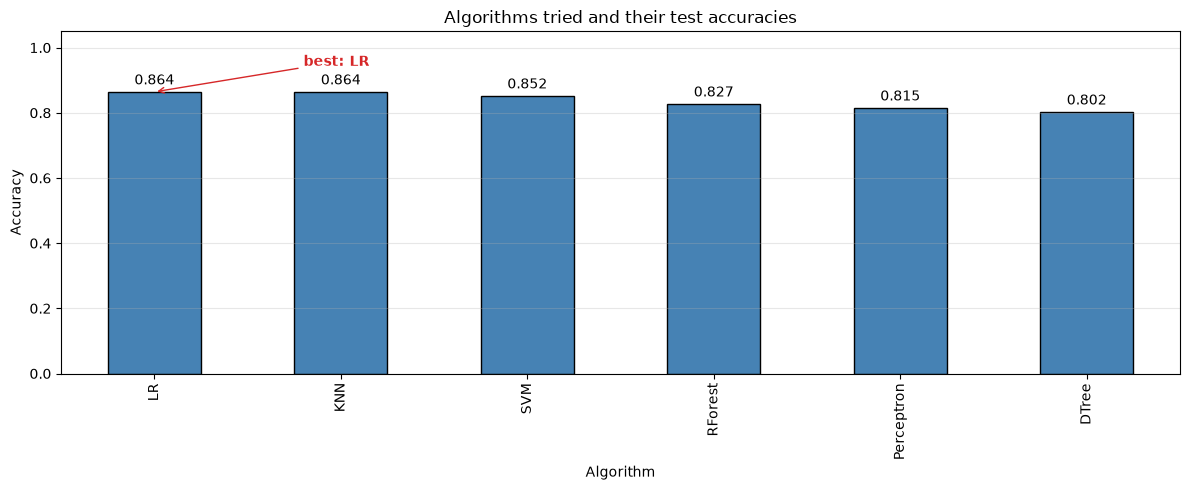

    Algorithm  Accuracy
1          LR  0.864198
5         KNN  0.864198
2         SVM  0.851852
4     RForest  0.827160
0  Perceptron  0.814815
3       DTree  0.802469


In [184]:
df_accuracy_results = df_accuracy_results.sort_values(
    by="Accuracy",
    ascending=False
)

ax = df_accuracy_results.plot.bar(
    x="Algorithm",
    y="Accuracy",
    figsize=(12, 5),
    legend=False,
    color="steelblue",
    edgecolor="k",
    title="Algorithms tried and their test accuracies",
)
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.05)
ax.grid(True, axis="y", alpha=0.3)
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)
best = df_accuracy_results.iloc[0]
ax.annotate(
    f"best: {best['Algorithm']}",
    xy=(0, best["Accuracy"]),
    xytext=(0.8, min(1.0, best["Accuracy"] + 0.08)),
    arrowprops=dict(arrowstyle="->", color="C3"),
    color="C3",
    fontsize=10,
    fontweight="bold",
)
plt.tight_layout()
plt.show()
print(df_accuracy_results)


## Create Voting Function


In [185]:
#accuracy_results_dict.values()


In [186]:
#pred_list_of_arrays = [item[1] for item in accuracy_results_dict.values()]


In [187]:
#pred_list_of_arrays


In [188]:
#sum_of_preds_list = []
#for pred_array in pred_list_of_arrays:
#    sum_of_preds_list.append(np.sum(pred_array))


In [189]:
#sum_of_preds_list


In [190]:
#len(accuracy_results_dict)


In [191]:
def ensemble_vote(algorithms_dict, tie_is_true=False):
    pred_list_of_arrays = [item[1] for item in algorithms_dict.values()]
    print(pred_list_of_arrays) # for debug
    
    #sum_of_preds_list = []
    
    #for pred_array in pred_list_of_arrays:
    #    sum_of_preds_list.append(np.sum(pred_array))
    #print(sum_of_preds_list)  # for debug

    sum_of_algorithms = np.sum(pred_list_of_arrays, axis = 0)
    print(sum_of_algorithms) # debug
    
    number_of_algorithms = len(algorithms_dict)
    print(number_of_algorithms) # debug

    threshold = 1.5 * number_of_algorithms
    print(threshold) # debug

    if tie_is_true:
        ensemble_results = np.where(sum_of_algorithms >= threshold, 2, 1)
    else:
        ensemble_results = np.where(sum_of_algorithms > threshold, 2, 1)

    return ensemble_results


In [192]:
#ensemble_vote(accuracy_results_dict)


## Sort Algorithms Dictionary Based on Accuracy


In [193]:
sorted_algorithms = dict(
    sorted(
        accuracy_results_dict.items(),
        key=lambda item: item[1][0],
        reverse=True
    )
)


In [194]:
#sorted_algorithms


### Get Top 3, Top 4, and Top 5 Best Accuracy Results


In [195]:
#accuracy_results_dict


In [196]:
top3 = dict(list(sorted_algorithms.items())[:3])
top4 = dict(list(sorted_algorithms.items())[:4])
top5 = dict(list(sorted_algorithms.items())[:5])


In [197]:
#top3


In [198]:
#top4


In [199]:
#top5


## Obtain Ensemble Predictions


In [200]:
predictions_from_3 = ensemble_vote(top3)
#predictions_from_3


[array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1]), array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1]), array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1])]
[3 3 3 6 6 3 3 3 6 6 6 3 6 6 6 3 3 3 6 6 3 3 3 6 3 3 3 3 3 3 3 3 6 3 3 3 3
 3 6 3 3 3 6 3 6 3 6 3 3 3 3 6 3 3 3 6 3 6 3 3 3 5 3 3 6 3 3 3 6 6 6 3 6 6
 6 3 6 3 3 6 3]
3
4.5


In [201]:
predictions_from_4 = ensemble_vote(top4, tie_is_true=True)
#predictions_from_4


[array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1]), array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1]), array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1]), array([1, 1, 1, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 2, 1, 1, 1, 2, 1, 

In [202]:
predictions_from_5 = ensemble_vote(top5)
#predictions_from_5


[array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1]), array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1]), array([1, 1, 1, 2, 2, 1, 1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 2, 1, 1,
       1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 1]), array([1, 1, 1, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 1,
       2, 1, 2, 2, 1, 1, 1, 2, 1, 

In [203]:
#


In [204]:
print(f"Top 3 ensemble: {100*accuracy_score(y_test.values, predictions_from_3):.2f}%")


Top 3 ensemble: 86.42%


In [205]:
print(f"Top 4 ensemble: {100*accuracy_score(y_test.values, predictions_from_4):.2f}%")
print("Ties were counted as YES")


Top 4 ensemble: 86.42%
Ties were counted as YES


In [206]:
print(f"Top 5 ensemble: {100*accuracy_score(y_test.values, predictions_from_5):.2f}%")


Top 5 ensemble: 86.42%


In [207]:
# The dominant methods are obtaining the majority vote; hence, all of the ensemble accuracies are identical


## Annotated model comparison

Bar chart of held-out test accuracy for each algorithm stored in `accuracy_results_dict`.
